In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

In [32]:
df = pd.read_csv("energy_consumption.csv")
df.head()

,timestamp,household_id,consumption_kwh,temperature,hour,day_of_week
0,2023-01-01 00:00:00,HH001,0.56,14.2,0,6
1,2023-01-01 00:00:00,HH002,1.00,17.0,0,6
2,2023-01-01 00:00:00,HH003,1.17,16.7,0,6
3,2023-01-01 00:00:00,HH004,0.90,10.3,0,6
4,2023-01-01 00:00:00,HH005,1.18,18.4,0,6


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43800 entries, 0 to 43799
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        43800 non-null  object 
 1   household_id     43800 non-null  object 
 2   consumption_kwh  43800 non-null  float64
 3   temperature      43800 non-null  float64
 4   hour             43800 non-null  int64  
 5   day_of_week      43800 non-null  int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 2.0+ MB


In [34]:
df.shape

(43800, 6)

In [35]:
df.isnull().sum()

timestamp          0
household_id       0
consumption_kwh    0
temperature        0
hour               0
day_of_week        0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['weekday'] = df['timestamp'].dt.weekday

In [38]:
df.head()

,timestamp,household_id,consumption_kwh,temperature,hour,day_of_week,day,weekday
0,2023-01-01,HH001,0.56,14.2,0,6,1,6
1,2023-01-01,HH002,1.00,17.0,0,6,1,6
2,2023-01-01,HH003,1.17,16.7,0,6,1,6
3,2023-01-01,HH004,0.90,10.3,0,6,1,6
4,2023-01-01,HH005,1.18,18.4,0,6,1,6


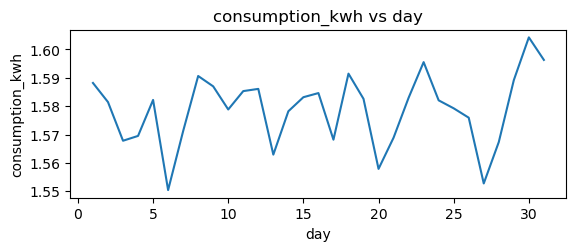

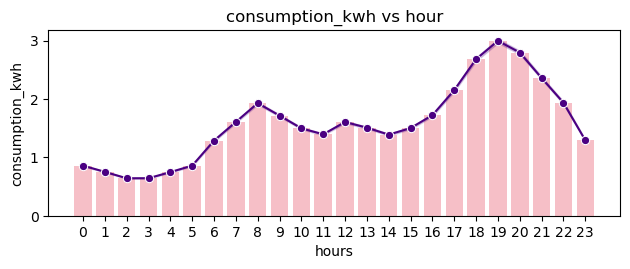

In [57]:
plt.subplot(2,1,1)
df.groupby('day')['consumption_kwh'].mean().plot(kind='line')
plt.title('consumption_kwh vs day')
plt.xlabel('day')
plt.ylabel('consumption_kwh')
plt.show()

plt.subplot(2,1,1)
sns.barplot(x='hour', y='consumption_kwh', data=df, color='lightpink')
sns.lineplot(x='hour', y='consumption_kwh', data=df, color='indigo', marker='o')
plt.title('consumption_kwh vs hour')
plt.xlabel('hours')
plt.ylabel('consumption_kwh')
plt.tight_layout()

# df.groupby('hour')['consumption_kwh'].mean().plot(kind='bar',color='green',width=0.8)
plt.show()



In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43800 entries, 0 to 43799
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   timestamp        43800 non-null  datetime64[ns]
 1   household_id     43800 non-null  object        
 2   consumption_kwh  43800 non-null  float64       
 3   temperature      43800 non-null  float64       
 4   hour             43800 non-null  int32         
 5   day_of_week      43800 non-null  int64         
 6   day              43800 non-null  int32         
 7   weekday          43800 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(1)
memory usage: 2.2+ MB


In [59]:
x=df[['hour','day_of_week','temperature']]
y=df['consumption_kwh']


In [60]:
x

,hour,day_of_week,temperature
0,0,6,14.2
1,0,6,17.0
2,0,6,16.7
3,0,6,10.3
4,0,6,18.4
...,...,...,...
43795,23,6,10.8
43796,23,6,17.9
43797,23,6,16.6
43798,23,6,15.8


In [61]:
y

0        0.56
1        1.00
2        1.17
3        0.90
4        1.18
         ... 
43795    1.11
43796    1.25
43797    1.41
43798    1.76
43799    1.41
Name: consumption_kwh, Length: 43800, dtype: float64

In [63]:
x_train,x_test, y_train, y_test=train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [64]:
model=LinearRegression()
model.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
y_pred=model.predict(x_test)

In [66]:
y_pred

array([1.16959431, 1.38113651, 2.17411546, ..., 0.98707521, 2.22859731,
       1.0468611 ], shape=(8760,))

In [67]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

In [68]:
print("RMSE : ",rmse)
print("R^2 : ",r2)

RMSE :  0.5909373454077429
R^2 :  0.42659533494493196


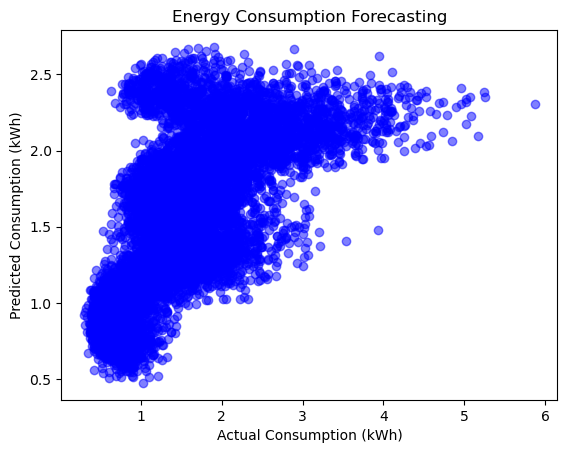

In [69]:
plt.scatter(y_test, y_pred, alpha=0.5, color="blue")
plt.xlabel("Actual Consumption (kWh)")
plt.ylabel("Predicted Consumption (kWh)")
plt.title("Energy Consumption Forecasting")
plt.show()